In [2]:
import yfinance as yf
import pandas as pd 
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.graph_objects as go

In [3]:
#yfinance.Ticker.history() method returns the adjusted prices by default, accounting for stock splits and dividends
#and other corporate actions. The Close column represents the adjusted close price. You need to set auto_adjust=False to get the raw close prices.
filepath = "data/abi.br.csv"
if os.path.exists(filepath):
    print(f"File {filepath} already exists. Loading data from file.")
    data = pd.read_csv(filepath, index_col=0, parse_dates=True)
else:
    ticker = yf.Ticker("ABI.BR")
    data = ticker.history(period="max",auto_adjust=False)

    data.to_csv(filepath)

File data/abi.br.csv already exists. Loading data from file.


In [4]:
# Filter data to show only after January 2006 (from February 2006 onwards)
# Make the timestamp timezone-aware to match the data index
filtered_data = data[data.index >= pd.Timestamp('2006-02-01').tz_localize('UTC')]

In [5]:
#Create fill similar to the Yahoo Finance mountain plot
# fill color green = fillcolor='rgba(0, 128, 0, 0.3)'
# line color green = line=dict(color='green')
fig = go.Figure()
fig.add_trace(go.Scatter(x=filtered_data.index, y=filtered_data['Close'], mode='lines', name='AB INBev Close Price', line=dict(color='#d94040', width=2), fill='tozeroy', fillcolor='rgba(217, 64, 64, 0.35)'))
fig.update_layout(
    title='AB INBEV Close Price',
    xaxis_title='Date',
    yaxis_title='Close Price',
    xaxis=dict(
        tickformat='%b %Y',
        dtick='M12',  # Yearly ticks
        showgrid=False
    ),
    yaxis=dict(showgrid=False),
    showlegend=True,
    width=1200,
    height=600,
    template='plotly_white'
)
fig.show()

<AxesSubplot:xlabel='Date'>

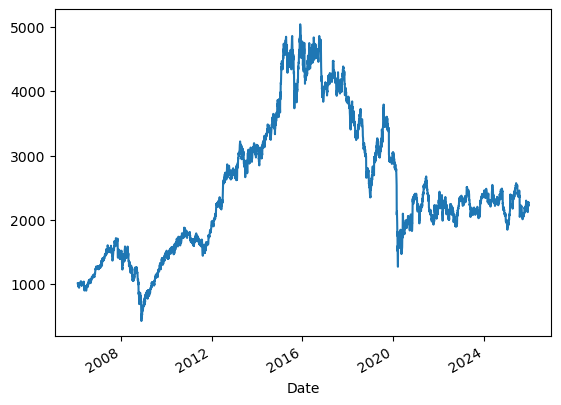

In [8]:
#The wealth index is a data series that presents the value of a portfolio at historical time periods 
#explaining the value at different points in time corresponding to the returns generated by it.
#below is an example of what has happened with invested 1000 EUR in AB INBEV from 2006 until now
dailychanges = filtered_data['Close'].pct_change()
dailychanges = dailychanges.dropna()
wealth_index = 1000*(1+dailychanges).cumprod()
wealth_index.plot.line()

<AxesSubplot:xlabel='Date'>

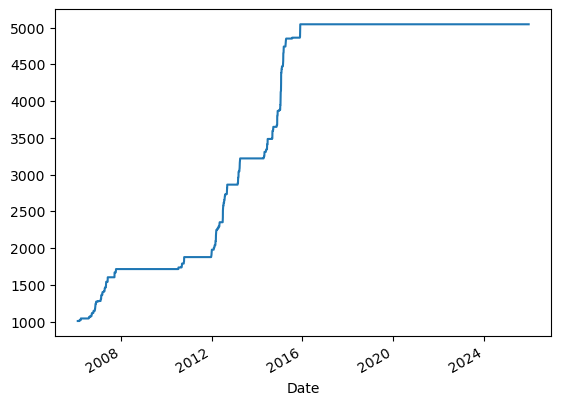

In [10]:
#AB INBEV hit it's highest price in 2016 and has been trading below this max ever since
previous_peaks = wealth_index.cummax()
previous_peaks.plot()

<AxesSubplot:xlabel='Date'>

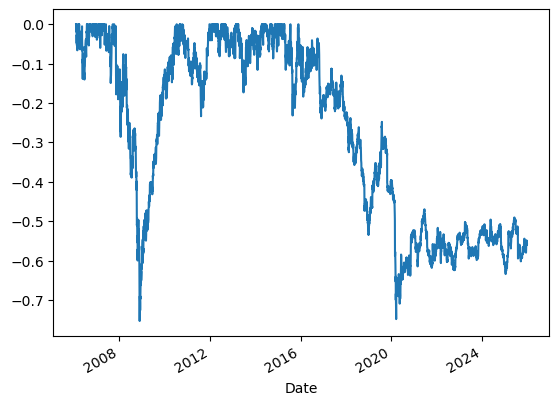

In [11]:
drawdown = (wealth_index - previous_peaks)/previous_peaks
drawdown.plot()

In [12]:
print('From its peak until the lowest price on '+ str(drawdown.idxmin()) 
      + '  - AB INBEV has lost ' + str(round(drawdown.min()*100,2)) + '% of its value')

From its peak until the lowest price on 2008-11-24 00:00:00+01:00  - AB INBEV has lost -75.36% of its value


In [19]:
# Calculate drawdown duration
below_peak = wealth_index < previous_peaks
groups = below_peak.groupby((below_peak != below_peak.shift()).cumsum())
durations = groups.sum()  # Sum of True values gives the length of each drawdown period

# Collect drawdown periods with start and end dates
drawdown_periods = []
for name, group in groups:
    if group.any():  # Only for periods where below_peak is True
        start_date = group.index[0]
        end_date = group.index[-1]
        duration = group.sum()
        drawdown_periods.append({'start': start_date, 'end': end_date, 'duration': duration})

# Find the maximum duration period
if drawdown_periods:
    max_period = max(drawdown_periods, key=lambda x: x['duration'])
    months = round(max_period["duration"] / 30.44, 1)
    print(f'Maximum drawdown duration: {max_period["duration"]} days ({months} months)')
    print(f'Start date: {max_period["start"].date()}')
    print(f'End date: {max_period["end"].date()}')
else:
    print('No drawdown periods found.')

Maximum drawdown duration: 2579 days (84.7 months)
Start date: 2015-11-27
End date: 2025-12-23


In [15]:
durations

Close
1         0
2         2
3         0
4        15
5         0
       ... 
180      68
181       0
182      89
183       0
184    2579
Name: Close, Length: 184, dtype: int64